<>:91: SyntaxWarning: invalid escape sequence '\p'
<>:94: SyntaxWarning: invalid escape sequence '\p'
<>:115: SyntaxWarning: invalid escape sequence '\p'
<>:91: SyntaxWarning: invalid escape sequence '\p'
<>:94: SyntaxWarning: invalid escape sequence '\p'
<>:115: SyntaxWarning: invalid escape sequence '\p'
C:\Users\gjsta\AppData\Local\Temp\ipykernel_4652\3344863131.py:91: SyntaxWarning: invalid escape sequence '\p'
  plt.text(2.5,-25,'$\phi$ = {}'.format(round(omega0,2)),fontsize=12)
C:\Users\gjsta\AppData\Local\Temp\ipykernel_4652\3344863131.py:94: SyntaxWarning: invalid escape sequence '\p'
  plt.text(23,-25,'$\phi$ = {}'.format(round(omega1,2)),fontsize=12)
C:\Users\gjsta\AppData\Local\Temp\ipykernel_4652\3344863131.py:115: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel('$\phi$ (degrees)')


A: c1A =  0.00912  d1A =  -1.82217  d0A =  0.83129
B: c1B =  0.00961 d1B =  -1.9167  d0B =  0.92632
C: d0 =  0.90484


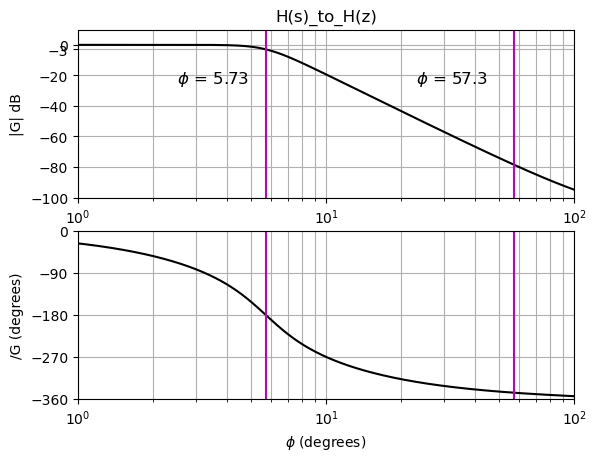

In [9]:
"""H(s)_to_H(z).py
5 pole Butterworth LPF
"""

import matplotlib.pyplot as plt
import numpy as np
from scipy import signal as sig
from math import pi, exp, cos, sin, log, sqrt
from control import margin
from control import tf
import cmath

NN = 100000
phi = np.linspace(0,2*pi,NN)

dt = .1
z = np.zeros(NN, dtype = complex)
H = np.zeros(NN, dtype = complex)
HA = np.zeros(NN, dtype = complex)
HB = np.zeros(NN, dtype = complex)
HC = np.zeros(NN, dtype = complex)

# First pair at 36 degrees (22.5 deg for 4 pole)
a0 = 1
a1 = 0
b0 = 1
b1 = 2*cos(22.5*pi/180)

alpha = b1/2
omega = sqrt(b0 - (b1/2)**2)
K1A = (a0 - a1*alpha)/omega
exaTA = exp(-alpha*dt)
omegTA = omega*dt
c1A = dt*K1A*exaTA*sin(omegTA)
d1A = -2*exaTA*cos(omegTA)
d0A = exaTA**2
print("A: c1A = ",round(c1A,5)," d1A = ",round(d1A,5),
        " d0A = ",round(d0A,5) )

# Second pair at 72 degrees (67.5 deg for 4 pole)
a0 = 1
a1 = 0
b0 = 1
b1 = 2*cos(67.5*pi/180)

alpha = b1/2
omega = sqrt(b0 - (b1/2)**2)
K1B = (a0 - a1*alpha)/omega
exaTB = exp(-alpha*dt)
omegTB = omega*dt
c1B = dt*K1B*exaTB*sin(omegTB)
d1B = -2*exaTB*cos(omegTB)
d0B = exaTB**2
print("B: c1B = ",round(c1B,5),
        "d1B = ",round(d1B,5)," d0B = ",round(d0B,5) )

# Single pole at 180 degrees (nonexistent for 4 pole)
a0 = 1
a1 = 0
b0C = exp(-dt)
print("C: d0 = ",round(b0C,5))

for n in range(0,NN):
    z = cmath.exp(1j*phi[n])
    
    num = c1A*z
    den = z**2 + d1A*z + d0A
    HA[n] = (num/den)
    
    num = c1B*z
    den = z**2 + d1B*z + d0B
    HB[n] = (num/den)
    
    HC[n] = dt/(z - b0C)
    
    H[n] = HA[n]*HB[n] #*HC[n]
    #Remove HC[n] for a 4 pole
    
omega0 = (1*dt*180/pi)
omega1 = (10*dt*180/pi)

plt.subplot(211)
plt.title('H(s)_to_H(z)')
plt.semilogx((180/pi)*phi,20*np.log10(H),'k')
#plt.plot((180/pi)*phi,abs(H),'k')
plt.axis([1,100, -100, 10])
#plt.xticks([2.865,3.15])
plt.yticks([0,-3,-20,-40,-60,-80,-100])
plt.ylabel('|G| dB'),-10
plt.axvline(omega0,color='m')
plt.text(2.5,-25,'$\phi$ = {}'.format(round(omega0,2)),fontsize=12)
3
plt.axvline(omega1,color='m')
plt.text(23,-25,'$\phi$ = {}'.format(round(omega1,2)),fontsize=12)

#plt.axvline(5.7,color='k')

plt.grid(which='both')

aaa = np.angle(H)
for n in range(NN):
    if aaa[n] > 0:
        aaa[n] = aaa[n] - 2*pi
    
plt.subplot(212)
plt.semilogx((180/pi)*phi,(180/pi)*aaa,'k')
#plt.plot((180/pi)*phi,(180/pi)*aaa,'k')
plt.ylabel('/G (degrees)')
plt.axis([1,100, -360,0])
plt.yticks([-360,-270,-180,-90,0])
plt.axvline(omega0,color='m')
plt.axvline(omega1,color='m')
#plt.text(2.5,-70,'$\phi$ = {}'.format(round(omegac,2)),fontsize=12)
plt.grid(which='both')
plt.xlabel('$\phi$ (degrees)')
#plt.savefig('H_zbode.png',dpi=300)
plt.show()

In [11]:
""" Six Pole """

NN = 100000
phi = np.linspace(0,2*pi,NN)

dt = .1
z = np.zeros(NN, dtype = complex)
H = np.zeros(NN, dtype = complex)
HA = np.zeros(NN, dtype = complex)
HB = np.zeros(NN, dtype = complex)
HC = np.zeros(NN, dtype = complex)

# First pair at 15 degrees
a0 = 1
a1 = 0
b0 = 1
b1 = 2*cos(15*pi/180)

alpha = b1/2
omega = sqrt(b0 - (b1/2)**2)
K1A = (a0 - a1*alpha)/omega
exaTA = exp(-alpha*dt)
omegTA = omega*dt
c1A = dt*K1A*exaTA*sin(omegTA)
d1A = -2*exaTA*cos(omegTA)
d0A = exaTA**2
print("A: c1A = ",round(c1A,5)," d1A = ",round(d1A,5),
        " d0A = ",round(d0A,5) )

# Second pair at 45 degrees
a0 = 1
a1 = 0
b0 = 1
b1 = 2*cos(45*pi/180)

alpha = b1/2
omega = sqrt(b0 - (b1/2)**2)
K1B = (a0 - a1*alpha)/omega
exaTB = exp(-alpha*dt)
omegTB = omega*dt
c1B = dt*K1B*exaTB*sin(omegTB)
d1B = -2*exaTB*cos(omegTB)
d0B = exaTB**2
print("B: c1B = ",round(c1B,5),
        "d1B = ",round(d1B,5)," d0B = ",round(d0B,5) )

#Third pair at 75 degrees
a0 = 1
a1 = 0
b0 = 1
b1 = 2*cos(75*pi/180)

alpha = b1/2
omega = sqrt(b0 - (b1/2)**2)
K1D = (a0 - a1*alpha)/omega
exaTD = exp(-alpha*dt)
omegTD = omega*dt
c1D = dt*K1D*exaTD*sin(omegTD)
d1D = -2*exaTD*cos(omegTD)
d0D = exaTD**2
print("D: c1D = ",round(c1D,5),
        "d1D = ",round(d1D,5)," d0D = ",round(d0D,5) )

A: c1A =  0.00908  d1A =  -1.81524  d0A =  0.82433
B: c1B =  0.00931 d1B =  -1.85881  d0B =  0.86812
D: c1D =  0.00973 d1D =  -1.93982  d0D =  0.94955


A: c1A =  0.01329  d1A =  -1.85318  d0A =  0.86727


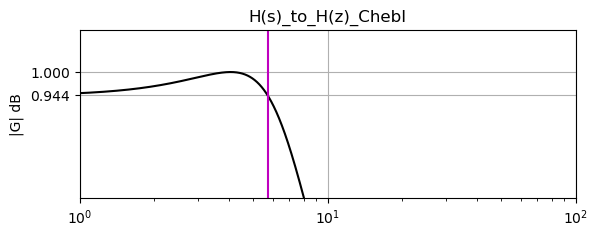

In [15]:
""" Cheb_I """

NN = 100000
phi = np.linspace(0,2*pi,NN)

dt = .1
z = np.zeros(NN, dtype = complex)
H = np.zeros(NN, dtype = complex)
HA = np.zeros(NN, dtype = complex)
HB = np.zeros(NN, dtype = complex)
HC = np.zeros(NN, dtype = complex)

#Pair on page 130
a0 = 1.429
a1 = 0
b0 = 1.514
b1 = 1.424

alpha = b1/2
omega = sqrt(b0 - (b1/2)**2)
K1A = (a0 - a1*alpha)/omega
exaTA = exp(-alpha*dt)
omegTA = omega*dt
c1A = dt*K1A*exaTA*sin(omegTA)
d1A = -2*exaTA*cos(omegTA)
d0A = exaTA**2
print("A: c1A = ",round(c1A,5)," d1A = ",round(d1A,5),
        " d0A = ",round(d0A,5) )

for n in range(0,NN):
    z = cmath.exp(1j*phi[n])
    
    num = c1A*z
    den = z**2 + d1A*z + d0A
    HA[n] = (num/den)
    
    H[n] = HA[n]

omega0 = (1*dt*180/pi)
omega1 = (2*dt*180/pi)

plt.subplot(211)
plt.title('H(s)_to_H(z)_ChebI')
plt.semilogx((180/pi)*phi,abs(H),'k')
#plt.plot((180/pi)*phi,abs(H),'k')
plt.axis([1,100, .7, 1.1])
#plt.xticks([2.865,3.15])
plt.yticks([.944,1])
plt.ylabel('|G| dB'),-10
plt.axvline(omega0,color='m')
plt.grid()